## Supervised Research (Law, Economics, and Data Science)

#### Project name "Anomaly Detection for CNP Transactions".

Student: Anna Kravchenko

akravchenko@student.ethz.ch

Student number: 22957856

### Part 2 - Feature Audit

#### Goal
This notebook performs a feature audit on the training data before preprocessing and modeling.
The objective is to identify which features are reliable, informative, and safe to carry forward.

The output of this notebook is an audited set of feature decisions and artifacts that will be used in the downstream preprocessing/modeling notebooks.

*Reproducibility notes.*
All diagnostics are computed on labeled training data using chronological logic.

Any performance metrics (AUC, target rates, PSI) are for exploring the data, not for picking the final model.

Sampling, when used for speed, is controlled with fixed random seeds.

All paths, thresholds, and generated artifacts should be versioned so results can be reproduced exactly.

### Setup

#### Imports

In [19]:
import os, gc, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

#### Display/plot settings

In [20]:
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 120)
plt.rcParams["figure.figsize"] = (10, 4)

#### Data load (raw tables)

In [21]:
#project paths
from pathlib import Path

#locally stored data
PROJECT_DIR = Path("/Users/kravchan/Downloads/Supervised Research/project")
DATA_DIR = PROJECT_DIR / "Data"

#to print nicely
def h(msg):
    print("\n" + "="*len(msg) + f"\n{msg}\n" + "="*len(msg))

#load data
train_tr = pd.read_csv(os.path.join(DATA_DIR, "train_transaction.csv"))
train_id = pd.read_csv(os.path.join(DATA_DIR, "train_identity.csv"))

#### Join and sanity checks
Left join on `TransactionID` keeps all transactions and attaches identity fields when available, confirming the merge is correct and there’s no ID duplication.

In [22]:
train = train_tr.merge(train_id, on="TransactionID", how="left")
print("joined train:", train.shape)

#% of transactions that have identity
overlap = train_tr["TransactionID"].isin(train_id["TransactionID"]).mean()
print(f"Share of transactions with identity: {overlap:.3%}")

joined train: (590540, 434)
Share of transactions with identity: 24.424%


#### Restore event_time

In this dataset, `TransactionDT` is stored as elapsed seconds from a reference start date, not as a calendar timestamp.
To perform time aware analysis, it will be converted into a real datetime column called `event_time` (create `event_time` from `TransactionDT` (epoch + timedelta)).

 `event_time` is needed for for chronological train/validation/test splits, daily/weekly trend analysis, and checks over time.

The function  handles merged-column variants (for example, `TransactionDT_x` / `TransactionDT_y`).

In [23]:
def event_time(df, epoch='2017-12-01'):
    if 'event_time' in df.columns:
        return df  

    #possible names after merge
    tdt_candidates = [c for c in df.columns if c.startswith('TransactionDT')]
    if not tdt_candidates:
        raise KeyError(
            "Time column not found: expected 'TransactionDT' or a merged variant "
            "like 'TransactionDT_x' / 'TransactionDT_y'."
        )
    tdt = tdt_candidates[0]
    df[tdt] = pd.to_numeric(df[tdt], errors='coerce')
    base = pd.Timestamp(epoch)
    #TransactionDT is seconds since a hidden reference date, so this turns it into a real timestamp we can use
    df['event_time'] = base + pd.to_timedelta(df[tdt], unit='s')
    return df

train = event_time(train)
print('event_time ready:', 'event_time' in train.columns, train['event_time'].dtype)

event_time ready: True datetime64[ns]


#### Chronological split preview
split the dataset by time using the 60% and 80% quantiles of event_time:

In [24]:
t1 = train["event_time"].quantile(0.6)
t2 = train["event_time"].quantile(0.8)

trn = train[train["event_time"] <  t1]
val = train[(train["event_time"]>= t1) & (train["event_time"]< t2)]
tst = train[train["event_time"]>= t2]

print("Train/Val/Test sizes:", len(trn), len(val), len(tst))
print("Fraud rates:", trn["isFraud"].mean().round(4), val["isFraud"].mean().round(4), tst["isFraud"].mean().round(4))

Train/Val/Test sizes: 354324 118108 118108
Fraud rates: 0.0338 0.039 0.0344


It is time-based because it prevents leakage and better mimics real deployment (from train in the past to predict the future).

It shows sizes of each split and their fraud rates. They are close (≈3-4%), so the splits look balanced and suitable for model development and evaluation.

### Data quality checks

#### Duplicates by TransactionID

In [25]:
print("Duplicates TransactionID in transaction:", train_tr["TransactionID"].duplicated().any())
print("Duplicates TransactionID in identity:   ", train_id["TransactionID"].duplicated().any())
print("Duplicates TransactionID in merged train:", train["TransactionID"].duplicated().any())
print("Duplicated rows in merged train by TransactionID:", train.duplicated(subset=["TransactionID"]).sum())
print("Exact duplicate rows in merged train:", train.duplicated().sum())

Duplicates TransactionID in transaction: False
Duplicates TransactionID in identity:    False
Duplicates TransactionID in merged train: False
Duplicated rows in merged train by TransactionID: 0
Exact duplicate rows in merged train: 0


#### Constant / near-constant features

In [26]:
const = []
near = []
for c in train.columns:
    vc = train[c].value_counts(dropna=False)
    if len(vc) <= 1: const.append(c)
    #flags a column as near-constant if its single most common value makes up more than 99.5% of all rows
    elif (vc.iloc[0] / len(train)) > 0.995: near.append(c)
print("Constant cols:", const[:10])
print("Near-constant (top):", near[:15])

Constant cols: []
Near-constant (top): ['C3', 'V107', 'V111', 'V113', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V305']


Constant features carry no information;
near-constant (e.g., >99.5% same value) are usually weak and can be pruned or heavily regularized.
The snapshot shows no strictly constant features and lists top near-constant `V` columns.

#### Negative / weird ranges sanity check (numeric)

In [27]:
print("Negative amounts:", (train["TransactionAmt"] < 0).sum() if "TransactionAmt" in train else 0)
for c in ["dist1","dist2"]:
    if c in train:
        hi = train[c].quantile(0.999) #compares the 99.9th percentile to the max value, a big gap between them will mean a handful of extreme outliers are stretching the range
        print(f"{c}: >=99.9th pct =", round(hi,2), "| max =", round(train[c].max(),2))

Negative amounts: 0
dist1: >=99.9th pct = 3247.44 | max = 10286.0
dist2: >=99.9th pct = 5991.09 | max = 11623.0


- No negative TransactionAmt were found.
- For distance-like features (`dist1`, `dist2`) it is the 99.9th percentile and the absolute max to see the tail thickness.
- The tails are heavy but plausible. Outlier handling should be robust.

#### High cardinality snapshot (categoricals that may need frequency encoding)
The printout with the rank object-type columns by the number of unique values. 

In [28]:
#selects all text-type columns, since those are the ones that might have too many unique values for simple one-hot encoding
obj_cols = train.select_dtypes(include="object").columns.tolist()
#how many distinct values each text column has, so the hardest to encode columns show up first
card = train[obj_cols].nunique(dropna=True).sort_values(ascending=False)
print("Top-15 high-cardinality categoricals:")
card.head(15)

Top-15 high-cardinality categoricals:


DeviceInfo       1786
id_33             260
id_31             130
id_30              75
R_emaildomain      60
P_emaildomain      59
ProductCD           5
id_34               4
card4               4
card6               4
id_15               3
id_23               3
M4                  3
M2                  2
DeviceType          2
dtype: int64

`DeviceInfo` is extremely high-cardinality (~1.8k uniques), followed by several `id_` fields (hundreds of uniques) and email domains. A few regular categoricals (`ProductCD`, `card4`/`card6`) have only a handful of levels.

One-hot encoding the very high-cardinality fields would explode the feature space and risks overfitting, so the frequency encoding will be applied to those instead. The medium-cardinality fields get a rare bucket for uncommon values plus a missingness flag, then standard one-hot encoding.

#### Outliers table
10 highest transaction amounts with a few context columns.

In [29]:
train.nlargest(10, "TransactionAmt")[["TransactionID","TransactionAmt","isFraud","card4","P_emaildomain","DeviceType"]]

,TransactionID,TransactionAmt,isFraud,card4,P_emaildomain,DeviceType
274336,3261336,31937.391,0,mastercard,yahoo.com,NaN
274339,3261339,31937.391,0,mastercard,yahoo.com,NaN
296021,3283021,6450.970,0,visa,yahoo.com,NaN
248413,3235413,6085.230,0,mastercard,NaN,NaN
384603,3371603,5543.230,0,visa,msn.com,NaN
275529,3262529,5420.000,0,mastercard,gmail.com,NaN
275535,3262535,5420.000,0,mastercard,gmail.com,NaN
584767,3571767,5366.820,0,visa,yahoo.com,NaN
303106,3290106,5279.950,0,mastercard,yahoo.com,NaN
315172,3302172,5279.950,0,visa,gmail.com,NaN


It confirms the heavy right tail in `TransactionAmt` and that these extremes are not labeled as fraud in train (all `isFraud` = 0), so a “large ⇒ fraud” rule would backfire.

It also shows lots of missing `DeviceType` at the top end.

#### Outlier summary for a few numeric anchors (amount, distances)
quick quantiles for three numeric features. 

In [30]:
num_anchors = [c for c in ["TransactionAmt","dist1","dist2"] if c in train.columns]
for c in num_anchors:
    s = train[c].dropna()
    #prints min, 1st/25th/50th/75th/99th percentiles and max, so extreme tail values can be compared against the bulk of the distribution
    q = s.quantile([0, .01, .25, .5, .75, .99, 1.0])
    print(f"\n{c} quantiles:\n{q}")


TransactionAmt quantiles:
0.00        0.251
0.01        9.244
0.25       43.321
0.50       68.769
0.75      125.000
0.99     1104.000
1.00    31937.391
Name: TransactionAmt, dtype: float64

dist1 quantiles:
0.00        0.0
0.01        0.0
0.25        3.0
0.50        8.0
0.75       24.0
0.99     2040.0
1.00    10286.0
Name: dist1, dtype: float64

dist2 quantiles:
0.00        0.00
0.01        0.00
0.25        7.00
0.50       37.00
0.75      206.00
0.99     2367.48
1.00    11623.00
Name: dist2, dtype: float64


For example, `TransactionAmt` jumps from median ≈ 68.8 to 99th pct ≈ 1 104 and max ≈ 31 937; both `dist1`/`dist2` are zero-inflated with very large 99th pct tails.

This confirms a skewed distribution with many zero values. I would keep these as raw numeric features, standardized for the distance-based models, left on their natural scale for the tree-based model, rather than applying a specific transform.

#### Rare-category snapshot (for later grouping)
enumerating of rare categories (<0.1% frequency) for key categoricals (card family, device/email domains). 

In [31]:
def rare_map(s, thr=0.001):
    freq = s.fillna("__MISSING__").value_counts(normalize=True) #computes what share of rows each category value makes up
    rares = set(freq[freq < thr].index) #collects every category value that makes up less than 0.1% of rows, to see how many rare values would need to be grouped later
    return rares

for c in ["ProductCD","card4","card6","DeviceType","DeviceInfo","P_emaildomain","R_emaildomain"]:
    if c in train:
        rares = rare_map(train[c], 0.001)
        print(f"{c}: {len(rares)} rare values (<0.1%)")

ProductCD: 0 rare values (<0.1%)
card4: 0 rare values (<0.1%)
card6: 2 rare values (<0.1%)
DeviceType: 0 rare values (<0.1%)
DeviceInfo: 1780 rare values (<0.1%)
P_emaildomain: 37 rare values (<0.1%)
R_emaildomain: 47 rare values (<0.1%)


Thousands of rare `DeviceInfo` values motivate either grouping rare labels into an "OTHER" bucket or using frequency encoding to control dimensionality and variance.

### Leakage + univariate signal

#### Leakage Smoke Test (single-feature AUC on validation)
computing single-feature AUC on the validation window for a few anchor features. 

In [32]:
from sklearn.metrics import roc_auc_score
leak_candidates = []
y_va = val["isFraud"]
for c in ["dist1","dist2","TransactionAmt","card1","card2","addr1","addr2"]:
    if c in trn.columns:
        x_va = val[c].fillna(-999)  #fills missing values with -999, a sentinel far outside the normal range, so a NaN doesnt break the AUC calculation 
        try:
            #checks if a single raw feature alone can predict fraud unusually well on its own, which would be a sign of leakage rather than a real pattern
            auc = roc_auc_score(y_va, x_va)
            leak_candidates.append((c, round(auc,4)))
        except Exception:
            pass
#sorts features by AUC from highest to lowest, so the strongest (most suspicious) single-feature predictors show up first
leak_candidates = sorted(leak_candidates, key=lambda x: -x[1])
print("Single-feature AUC on val (higher can flag leakage):", leak_candidates[:10])

Single-feature AUC on val (higher can flag leakage): [('dist2', 0.5532), ('TransactionAmt', 0.5059), ('card2', 0.4963), ('card1', 0.4874), ('dist1', 0.3994), ('addr1', 0.3617), ('addr2', 0.3451)]


Very high AUC for a single raw column may indicate a temporal join mismatch or hidden leakage. 

Here, the top anchors (e.g., `dist2`, `TransactionAmt`, `card2`) yield AUC in the 0.34–0.55 range, which is not suspiciously high but worth monitoring.

#### Single-feature importance screen
ranking numeric features by mutual information with the target on the train split (with isFraud on a time-respecting training slice (event_time < 80th percentile)).

In [33]:
#ranks numeric features by mutual information with the target
from sklearn.feature_selection import mutual_info_classif

#we could use a specific date or calculate it
t1 = train["event_time"].quantile(0.8)  # using 80% of data for training

num_cols = [c for c in train.select_dtypes(include=[np.number]).columns if c != "isFraud"]
X_tr = train.loc[train["event_time"]<t1, num_cols].fillna(0)
y_tr = train.loc[train["event_time"]<t1, "isFraud"].astype(int)

mi = mutual_info_classif(X_tr, y_tr, discrete_features=False, random_state=0)
imp = pd.Series(mi, index=num_cols).sort_values(ascending=False)
display(imp.head(25).to_frame("mutual_info"))

,mutual_info
V123,0.126878
V114,0.125575
V110,0.113150
V305,0.109083
V122,0.108651
V24,0.104137
V112,0.103855
V23,0.103653
V115,0.100691
V67,0.099200


Higher mutual information means a feature carries more standalone signal about fraud (not necessarily linear).

In this run, the top signals are dominated by `V` features (for example `V123`, `V114`, `V110`, `V305`), so the `V`-block contains strong predictive information.

This screening tool for prioritization candidates for deeper audit does not prove causality or model usefulness by itself.
Final feature decisions still require more checks, validation, and multicollinearity handling.

#### Bivariate decile scans
for several core numeric features we bin values into deciles and compute the fraud rate per bin. This reveals shape effects (monotonic or U-shaped relationships) and potential thresholds. 

In [34]:
to_check = [c for c in ["TransactionAmt","card1","card2","addr1","dist1","dist2"] if c in train]
#fills missing values with the median, then splits the column into 10 equal sized groups 
#so the fraud rate can be compared across the range of values
for c in to_check:
    bins = pd.qcut(train[c].fillna(train[c].median()), 10, duplicates="drop")
    curve = train.groupby(bins)["isFraud"].mean() #computes the fraud rate within each decile bin, to see whether risk rises, falls, or has a U-shape across the range
    print(f"\nFraud rate by decile — {c}")
    display(curve.to_frame("fraud_rate"))


Fraud rate by decile — TransactionAmt


,fraud_rate
TransactionAmt,
"(0.25, 25.95]",0.055889
"(25.95, 35.95]",0.032052
"(35.95, 49.0]",0.032250
"(49.0, 57.95]",0.019431
"(57.95, 68.769]",0.028513
"(68.769, 100.0]",0.036170
"(100.0, 117.0]",0.019742
"(117.0, 159.95]",0.043026
"(159.95, 275.293]",0.038037



Fraud rate by decile — card1


,fraud_rate
card1,
"(999.999, 2803.0]",0.035349
"(2803.0, 4908.0]",0.040554
"(4908.0, 6951.0]",0.037248
"(6951.0, 8135.0]",0.024014
"(8135.0, 9678.0]",0.049216
"(9678.0, 11313.0]",0.042737
"(11313.0, 12932.0]",0.025255
"(12932.0, 15111.0]",0.040534
"(15111.0, 16582.1]",0.029889



Fraud rate by decile — card2


...

,fraud_rate
addr1,
"(99.999, 181.0]",0.025326
"(181.0, 204.0]",0.022533
"(204.0, 251.0]",0.025906
"(251.0, 272.0]",0.022958
"(272.0, 299.0]",0.077971
"(299.0, 325.0]",0.023982
"(325.0, 330.0]",0.028921
"(330.0, 441.0]",0.025469
"(441.0, 540.0]",0.026738



Fraud rate by decile — dist1


,fraud_rate
dist1,
"(-0.001, 3.0]",0.018267
"(3.0, 8.0]",0.041528
"(8.0, 9.0]",0.018892
"(9.0, 25.0]",0.016664
"(25.0, 10286.0]",0.027847



Fraud rate by decile — dist2


,fraud_rate
dist2,
"(-0.001, 37.0]",0.032795
"(37.0, 11623.0]",0.101728


For example, `TransactionAmt` shows elevated fraud rate in the highest decile; `card1`/`card2` exhibit heterogeneous risk across ranges, and `dist2` has a markedly higher rate for the largest bin.

### Drift/stability audits

#### Category drift over time (example: `P_emaildomain`)
The chart will tracks a 30-day rolling fraud rate for the five largest `P_emaildomain` categories. 

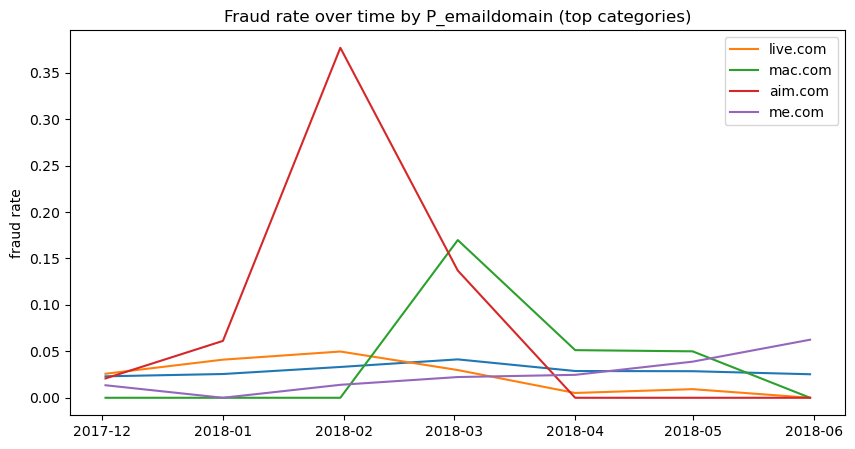

In [35]:
col = "P_emaildomain"
if col in train.columns:
    tmp = (train.assign(cat=train[col].fillna("__MISSING__"))
           .set_index("event_time")
           #groups rows into 30-day buckets combined with category, to track how fraud rate for each category changes over time
           .groupby([pd.Grouper(freq="30D"), "cat"])["isFraud"]
           .mean()
           .reset_index())
    top_cats = tmp.groupby("cat")["isFraud"].size().sort_values(ascending=False).head(5).index
    plt.figure(figsize=(10,5))
    for k in top_cats:
        #smooths the fraud rate for this category with a 30-day rolling window so short-term noise does not dominate the plot
        s = tmp.loc[tmp["cat"]==k].set_index("event_time")["isFraud"].rolling("30D").mean()
        plt.plot(s.index, s.values, label=k)
    plt.legend(); plt.title("Fraud rate over time by P_emaildomain (top categories)")
    plt.ylabel("fraud rate"); plt.show()

Here is a category-specific drift: aim.com's fraud rate spikes sharply around early 2018 while other domains stay flat or peak at different times. This kind of transient, provider specific burst is exactly why it is better to use a strictly chronological split and check model stability over time, rather than trusting a single global fraud-rate number. It also supports pooling very small domains into a rare bucket instead of treating each one as its own category.

#### Monthly PSI (population stability index)
The comparison (for each month after the first) of the month’s distribution to Month-1 using PSI (after binning the feature globally to deciles and adding a “MISSING” bin).

In [36]:
#a couple of features to watch
psi_cols = [c for c in ["TransactionAmt","card1"] if c in train.columns]

#monthly bins
train["month"] = train["event_time"].dt.to_period("M").astype(str)

#measures how much a feature's distribution has shifted between two time periods
def psi(actual, expected, eps=1e-9):
    # actual/expected are counts normalized to probabilities over same bins
    return np.sum((actual - expected) * np.log((actual + eps) / (expected + eps)))

for col in psi_cols:
    print(f"\nPSI over months for {col}")
    #bin numeric into deciles per overall distribution (so bins are fixed)
    try:
        binned = pd.qcut(train[col], 10, duplicates="drop") 
    except Exception:
        #if too many NaNs or low unique, then skip
        print("  skipped (qcut failed)")
        continue
    train["_bin"] = binned.astype(str).fillna("__MISSING__")
    months = sorted(train["month"].unique())
    base = train.loc[train["month"]==months[0], "_bin"].value_counts(normalize=True)
    for m in months[1:]:
        cur = train.loc[train["month"]==m, "_bin"].value_counts(normalize=True)
        #align indices
        aligned = pd.concat([base, cur], axis=1).fillna(0)
        s = psi(aligned.iloc[:,1].values, aligned.iloc[:,0].values)
        print(f"  {m}: PSI={s:.3f}")
    train.drop(columns=["_bin"], inplace=True)


PSI over months for TransactionAmt
  2018-01: PSI=0.096
  2018-02: PSI=0.094
  2018-03: PSI=0.102
  2018-04: PSI=0.095
  2018-05: PSI=0.091
  2018-06: PSI=0.120

PSI over months for card1
  2018-01: PSI=0.003
  2018-02: PSI=0.002
  2018-03: PSI=0.003
  2018-04: PSI=0.003
  2018-05: PSI=0.005
  2018-06: PSI=0.013


As a rule of thumb: PSI < 0.10 = small/none, 0.10–0.25 = moderate shift, >0.25 = major shift.

TransactionAmt: monthly PSI is ~0.09–0.10, which is right at the small/ borderline moderate edge. The shape of amounts is reasonably stable but does nudge around month-to-month, so later it is preferable to do time-aware validation and avoid calibrating thresholds on pooled data.

card1: monthly PSI ~0.00–0.01, which is essentially stable; distributional changes are negligible. If we later see performance changes, they are unlikely driven by card1 drift.

Based o that, `TransactionAmt` is heavy-tailed and slightly drifting over time with no missingness; `card1` is stable; fraud appears across the time span with more high-value points.

#### Train/Val/Test drift guard (PSI summary table)
Lets check PSI between train vs val on a few features.
Here bin edges are fit on train only, then reused (pd.cut) for val, so both splits compare against the same bins.

In [37]:
def psi_simple(a, b, eps=1e-9):
    a = a / (a.sum() + eps); b = b / (b.sum() + eps)
    return np.sum((a - b) * np.log((a + eps) / (b + eps)))

cols = [c for c in ["TransactionAmt","card1","card2","addr1"] if c in train]
for c in cols:
    try:
        trn_binned, bin_edges = pd.qcut(trn[c], 10, duplicates="drop", retbins=True) #splits train into 10 deciles and keeps the actual bin edges
        b_tr = trn_binned.astype(str).value_counts().sort_index() #exact same cut points from the above 
        val_binned = pd.cut(val[c], bins=bin_edges, include_lowest=True)
        b_va = val_binned.astype(str).value_counts().sort_index()
        aligned = pd.concat([b_tr, b_va], axis=1).fillna(0)
        s = psi_simple(aligned.iloc[:,0].values, aligned.iloc[:,1].values)
        print(f"PSI(train vs val) for {c}: {s:.3f}")
    except Exception as e:
        print(f"  skipped {c}: {e}")

PSI(train vs val) for TransactionAmt: 0.014
PSI(train vs val) for card1: 0.000
PSI(train vs val) for card2: 0.011
PSI(train vs val) for addr1: 0.003


Larger PSI indicates distributional mismatch; here, some cards features show sizeable shifts, which argues for time-aware CV, robust encodings, and regularization. 

Models should be validated on future-like windows to avoid optimistic estimates.

#### Computed PSI for 30/30 columns
Monthly PSI shows how each features distribution shifts vs the first month. 

In [38]:
#picks a few key columns plus the first 30 V-columns to check for drift, since checking every column would be slow
cols = [c for c in train.columns if c in ["TransactionAmt","card1","addr1","dist2"] or c.startswith("V")][:30]
train["month"] = train["event_time"].dt.to_period("M").astype(str)

#same PSI idea as earlier: compares two distributions bin by bin and sums up how different they are
def psi(a,b,eps=1e-9): 
    return np.sum(a*np.log((a+eps)/(b+eps)))

def psi_over_months(col):
    try:
        #first figures out how many bins actually work for this column 
        binned = pd.qcut(train[col].dropna(), 10, duplicates="drop")
        tmp = train[[col,"month"]].copy()
        #re-bins the full column, NaNs included this time, using that same number of bins so every row lands in a bin
        tmp["_bin"] = pd.qcut(train[col], len(binned.cat.categories), duplicates="drop")
        months = sorted(tmp["month"].unique())
        #uses the first month as the baseline distribution that every later month gets compared against
        base = tmp[tmp["month"]==months[0]]["_bin"].value_counts(normalize=True)
        out = []
        for m in months[1:]:
            cur = tmp[tmp["month"]==m]["_bin"].value_counts(normalize=True)
            aligned = pd.concat([base, cur], axis=1).fillna(0)
            #computes how much this month's bin distribution has drifted away from the baseline month
            out.append({"month": m, "psi": psi(aligned.iloc[:,0].values, aligned.iloc[:,1].values)})
        return pd.DataFrame(out)
    except Exception:
        return None

#runs the whole PSI-over-time check for every column in the list, storing each column's monthly PSI table in a dictionary
drifts = {c: psi_over_months(c) for c in cols}

#keep only the columns where the PSI calculation actually worked and returned some months of data
valid = {k: v for k, v in drifts.items() if v is not None and len(v)}

print(f"Computed PSI for {len(valid)}/{len(drifts)} columns.")
# shows 3 features 
from IPython.display import display
for k in list(valid.keys())[:3]:
    print(f"\nPSI over months for: {k}")
    display(valid[k].head())

Computed PSI for 30/30 columns.

PSI over months for: TransactionAmt


,month,psi
0,2018-01,0.048267
1,2018-02,0.047240
2,2018-03,0.051048
3,2018-04,0.047381
4,2018-05,0.045191



PSI over months for: card1


,month,psi
0,2018-01,0.001431
1,2018-02,0.000753
2,2018-03,0.001693
3,2018-04,0.001678
4,2018-05,0.002609



PSI over months for: addr1


,month,psi
0,2018-01,0.001767
1,2018-02,0.001762
2,2018-03,0.001656
3,2018-04,0.001355
4,2018-05,0.002478


Values stay well below 0.10 for `TransactionAmt`, `card1`, and `addr1`, showing no drift. Minor month to month nudges are visible but not operationally concerning.

#### PSI Summary
This summary ranks features by drift. 

In [39]:
rows = []
for col, df in valid.items():
    rows.append({
        "feature": col,
        "mean_psi": df["psi"].mean(),
        "max_psi": df["psi"].max(),
        "last_month_psi": df["psi"].iloc[-1]
    })
#summarizes each column's drift into three numbers (the average PSI across months, the worst single-month PSI, and the most recent month's PSI)
psi_summary = (pd.DataFrame(rows)
               .sort_values(["max_psi","mean_psi"], ascending=False))
display(psi_summary.head(20))

,feature,mean_psi,max_psi,last_month_psi
3,dist2,0.046255,0.088903,0.088903
0,TransactionAmt,0.050071,0.061298,0.061298
12,V9,0.006604,0.025181,0.025181
6,V3,0.007704,0.021765,0.021765
5,V2,0.006957,0.017227,0.017227
11,V8,0.005620,0.016561,0.016561
10,V7,0.004917,0.015951,0.015951
9,V6,0.005265,0.013915,0.013915
8,V5,0.003039,0.012126,0.012126
7,V4,0.003739,0.009741,0.009741


`dist2` and `TransactionAmt` have the highest mean/max PSI but remain <0.10 showing low risk. 

`V`-features show small drift; 

`card1`/`addr1` are very stable.

#### Monthly PSI (line plots)

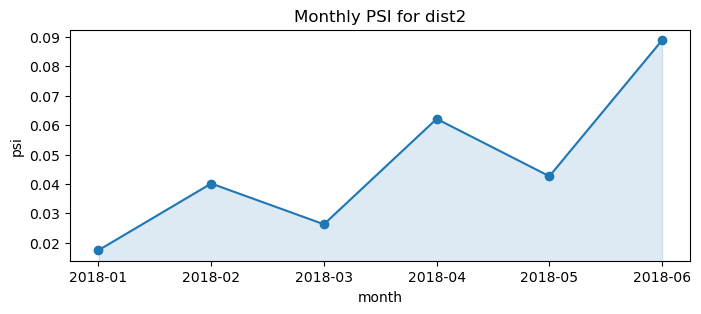

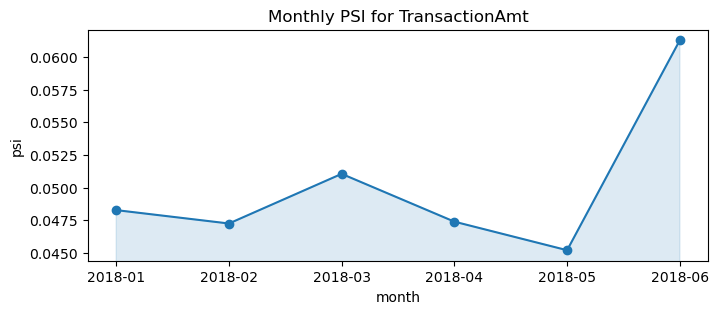

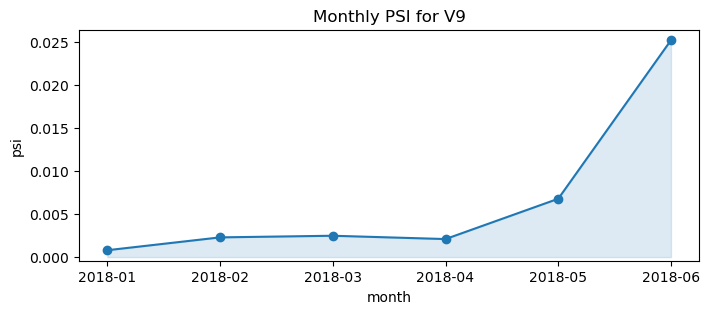

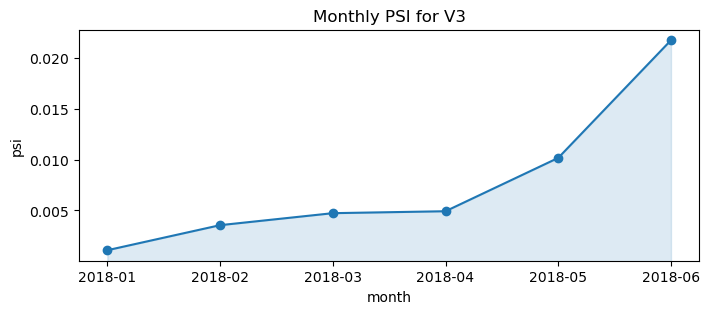

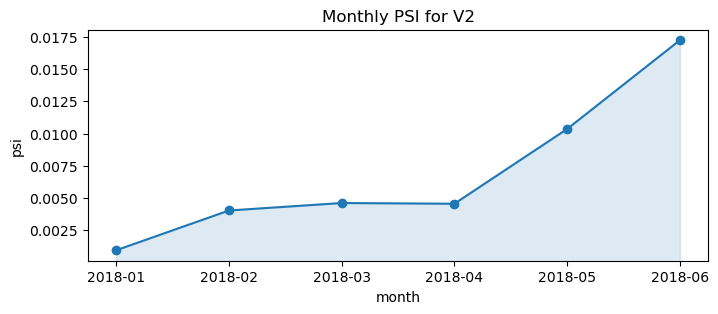

In [42]:
def plot_monthly_psi(col):
    df = valid.get(col)
    if df is None or df.empty:
        print(f"No PSI for {col}")
        return
    ax = df.plot(x="month", y="psi", figsize=(8,3), marker="o", legend=False)
    ylim = ax.get_ylim()  #remember the tight auto-scaled range before adding the fill
    ax.fill_between(df["month"], df["psi"], color="#1f77b4", alpha=0.15)
    ax.set_ylim(ylim)  #for restoring it so the shaded area doesnot pull the axis down to 0
    ax.set_title(f"Monthly PSI for {col}")
    ax.set_ylabel("psi"); ax.set_xlabel("month")

top5 = psi_summary.head(5)["feature"].tolist() #example top 5 by max_psi
for c in top5:
    plot_monthly_psi(c)

For `dist2` and `TransactionAmt`, both drift upward over time with a bump in June, but PSI stays under 0.09 for `dist2` and 0.062 for `TransactionAmt`, so with small drift. Still, worth watching that late-period increase when set up validation.

`V`-features from `V9` to `V3` show low but rising drift toward the end of the window (still under 0.03), possibly a calendar effect. They're safe to use, but I'll stick with time-split validation rather than a random split.
`V2` stays very stable, climbing gradually to about 0.017, well below the usual 0.10 warning threshold, so low risk of temporal leakage here.

#### Defining D block and C block

In [43]:
C_cols = [c for c in train.columns if c.startswith("C")]
C_cols = [c for c in C_cols if train[c].dtype.kind in "biufc"]
D_cols = [c for c in train.columns if c.startswith("D")]
D_cols = [c for c in D_cols if train[c].dtype.kind in "biufc"]

#### C/D monthly drift (PSI summary table)
Check of the maximum monthly PSI per feature, using the first month as baseline and comparing each later month’s binned distribution to it.
Higher PSI means stronger distribution drift over time.

In [44]:
def psi_simple(a,b,eps=1e-9):
    a = a/(a.sum()+eps); b = b/(b.sum()+eps)
    return np.sum((a-b)*np.log((a+eps)/(b+eps)))

sel = C_cols[:5] + D_cols[:5] ##checks drift on just the first 5 C-block and first 5 D-block columns
rows = []
for c in sel:
    try:
        bins = pd.qcut(train[c], 10, duplicates="drop") #bins the whole column into deciles once using the full dataset's distribution as the reference bin edges
    except Exception:
        continue
#attaches the bin label and the calendar month to each row, so rows can be grouped by month and compared bin by bin
    tmp = train.assign(_bin=bins, month=train["event_time"].dt.to_period("M").astype(str)) 
    months = sorted(tmp["month"].unique())
    base = tmp[tmp["month"]==months[0]]["_bin"].value_counts(normalize=True)
    mx = 0.0
    for m in months[1:]:
#gets this month's bin distribution, to be compared against the baseline right below
        cur = tmp[tmp["month"]==m]["_bin"].value_counts(normalize=True)
        #takes the union of bin labels from both months 
        #so a bin that only shows up in one month still gets compared, with 0 filled in for the other
        idx = sorted(set(base.index)|set(cur.index))
        s = psi_simple(base.reindex(idx, fill_value=0), cur.reindex(idx, fill_value=0))
        mx = max(mx, s)
    #keeps only the worst (highest) PSI seen across all months for this feature, as a single drift score
    rows.append({"feature": c, "max_monthly_psi": mx})
pd.DataFrame(rows).sort_values("max_monthly_psi", ascending=False)

,feature,max_monthly_psi
8,D4,0.208847
5,D1,0.154605
6,D2,0.096793
1,C2,0.079966
0,C1,0.059821
4,C5,0.030535
9,D5,0.015281
7,D3,0.014610
3,C4,0.012478
2,C3,0.000000


based on the output, 
- `D4` (0.209) and `D1` (0.155) show the largest drift and should be monitored closely.
- `D2` is near the common warning boundary (0.097).
- `C1`, `C2`, `C5` show mild drift.
- `C3` is essentially stable in this setup.

Thus, time shift is concentrated in specific `D` features, while most selected `C` features are relatively stable. This is exactly why I use a chronological split instead of a random one, so features like `D4`/`D1` that drift over time would give an overly optimistic performance estimate under random validation.

### Normalization + feature engineering audit


#### Target rates by frequent categories
Here are the fraud rates for the most frequent categories (above the minimum count threshold) in key categorical features such as `card1`, `card2`, `card4`, `card6`, and normalized email/device fields.

In [45]:
def top_target_rates(col, min_count=1000, k=20):
    vc = train[col].value_counts()
    #only keeps category values that appear at least min_count times, so rare values with noisy fraud rates do not dominate the top list
    top = vc[vc >= min_count].index
    fr = train[train[col].isin(top)].groupby(col)["isFraud"].mean().rename("fraud_rate")
    return fr.sort_values(ascending=False).head(k).to_frame()

for c in ["card1","card2","card4","card6","P_email_prov","device_brand","device_platform"]:
    if c in train.columns:
        print(f"\nTarget rate by {c} (frequent only):")
        display(top_target_rates(c))


Target rate by card1 (frequent only):


,fraud_rate
card1,
9026,0.191233
8755,0.179279
9633,0.178451
2256,0.174981
16062,0.142152
15063,0.126487
9002,0.114151
5812,0.111427
13832,0.095053



Target rate by card2 (frequent only):


,fraud_rate
card2,
177.0,0.241169
142.0,0.240356
130.0,0.239257
296.0,0.191971
500.0,0.180575
103.0,0.099481
548.0,0.098891
327.0,0.088627
204.0,0.087508



Target rate by card4 (frequent only):


,fraud_rate
card4,
discover,0.077282
visa,0.034756
mastercard,0.034331
american express,0.028698



Target rate by card6 (frequent only):


,fraud_rate
card6,
credit,0.066785
debit,0.024263


Here, category-level risk differs substantially, some `card1`/`card2` values and `card6`=credit have much higher fraud rates than others. 

Keeping only frequent categories reduces noise from rare values and makes the comparison more reliable.

These are only diagnostic summaries, not final encodings, for modeling, I use frequency encoding (fit on the train split only) rather than encoding categories by their fraud rate directly, which would risk leaking the target into the features.

#### Email provider/TLD normalization block
This step decomposes email domains into two interpretable features - provider (e.g., gmail, yahoo, outlook), and TLD/zone (e.g., com, net, mx)

In [46]:
def split_email(x):
    if not isinstance(x, str) or "." not in x: 
        return pd.Series([np.nan, np.nan])
    parts = x.lower().split(".")
    tld = parts[-1]
    #most domains split into exactly 2 parts (name.tld), but some have a subdomain (name.co.uk), so this takes the second-to-last part as the provider in that case
    provider = parts[0] if len(parts)==2 else parts[-2]
    return pd.Series([provider, tld])

for side in ["P_emaildomain","R_emaildomain"]:
    if side in train:
        train[[f"{side}_provider", f"{side}_tld"]] = train[side].apply(split_email)

for side in ["P_emaildomain_provider","P_emaildomain_tld"]:
    if side in train:
        fr = (train.assign(cat=train[side].fillna("__MISSING__"))
                   .groupby("cat")["isFraud"].agg(["mean","count"])
                   .sort_values("count", ascending=False).head(20))
        display(fr)

,mean,count
cat,,
gmail,0.043542,228355
yahoo,0.022748,101285
__MISSING__,0.029499,94952
hotmail,0.052644,45893
anonymous,0.023217,36998
aol,0.021811,28289
comcast,0.031187,7888
icloud,0.031434,6267
outlook,0.097398,5534


,mean,count
cat,,
com,0.037005,466477
__MISSING__,0.029499,94952
net,0.018662,24542
mx,0.023209,2499
es,0.090080,877
de,0.000000,506
fr,0.010121,494
uk,0.000000,161
jp,0.000000,32


The output tables show fraud rate (mean) and support size (count) for frequent categories.
There is are meaningful risk differences across providers and TLD groups, while `MISSING` remains a large segment and is treated explicitly.

This step matters because normalization reduces raw-domain cardinality and noise, creates stable categorical features for modeling, preserving signal from both known providers and missing/rare cases via explicit categories.

#### Email normalization 
This step maps raw email domains into normalized provider groups (`P_email_prov`), extracts TLD (`P_email_tld`), and creates a binary flag for free-email providers (`P_email_is_free`), as a result showing fraud rates by normalized provider.

In [47]:
if "P_emaildomain" in train.columns:
    dom = train["P_emaildomain"].fillna("unknown").str.lower().str.strip()

    prov_map = { #map common providers
        "gmail.com":"gmail","googlemail.com":"gmail","yahoo.com":"yahoo","yahoo.co.uk":"yahoo",
        "hotmail.com":"hotmail","outlook.com":"outlook","outlook.es":"outlook","live.com":"live",
        "icloud.com":"icloud","aol.com":"aol","msn.com":"msn","protonmail.com":"proton",
        "yandex.ru":"yandex","mail.com":"mail","gmx.com":"gmx"
    }
    train["P_email_prov"] = dom.map(prov_map).fillna(dom.str.split(".").str[0])
    train["P_email_tld"]  = dom.str.split(".").str[-1] 
    free_set = {"gmail","yahoo","hotmail","outlook","live","icloud","aol","proton","yandex","mail","gmx","msn"}
    train["P_email_is_free"] = train["P_email_prov"].isin(free_set).astype("int8")

    #target rates
    display(train.groupby("P_email_prov")["isFraud"].mean().rename("fraud_rate").sort_values(ascending=False).head(15).to_frame())

,fraud_rate
P_email_prov,
proton,0.407895
mail,0.189624
aim,0.126984
outlook,0.097398
hotmail,0.052516
gmail,0.043496
embarqmail,0.034615
live,0.032501
mac,0.032110


- Provider level risk differs substantially, indicating meaningful signal in normalized email features.
- Very high rates for some providers should be treated cautiously and checked against support size before drawing strong conclusions.
- Normalization helps reduce raw-domain sparsity and creates cleaner features for downstream modeling.

#### Device normalization
This block cleans raw DeviceInfo, extracts a normalized device_brand, and derives a coarse device_platform category (e.g., Apple, Windows, Linux, Android/Other).
It then reports fraud rates by normalized brand.

In [48]:
import re
def _norm_device(s):
    s = str(s).lower()
    s = re.sub(r"\s+", " ", s) #collapses multiple spaces into one (formatting differences do not cause the same device to be counted as two)
    return s

if "DeviceInfo" in train.columns:
    di = train["DeviceInfo"].fillna("unknown").map(_norm_device)
    train["device_brand"] = (
        #pulls out a known brand keyword from the device string if there is one, otherwise labels it "other"
        di.str.extract(r"(samsung|huawei|motorola|sony|lg|asus|xiaomi|oneplus|lenovo|nexus|iphone|ipad|mac|windows|linux)", expand=False)
          .fillna("other")
    )
    #platform coarse
    #groups devices based on keywords in the device string
    train["device_platform"] = np.where(di.str.contains("iphone|ipad|mac|ios"), "apple",
                                np.where(di.str.contains("windows"), "windows",
                                np.where(di.str.contains("linux"), "linux",
                                "android/other")))
    #shows count alongside fraud_rate so rates of 1.0 from tiny (n=1-2) groups are visible,
    #not mistaken for a strong signal (e.g. device_brand="iphone" turned out to be n=1-2 rows).
    _brand_stats = (train.groupby("device_brand")["isFraud"]
                     .agg(count="size", fraud_rate="mean")
                     .sort_values("fraud_rate", ascending=False))
    display(_brand_stats.head(12))

,count,fraud_rate
device_brand,,
iphone,1,1.000000
lenovo,318,0.147799
huawei,2415,0.135818
nexus,85,0.129412
lg,2563,0.104565
samsung,2692,0.081724
windows,47775,0.065536
other,521937,0.031381
mac,12573,0.022111


- Device normalization converts noisy text into structured categorical features.
- Fraud rates differ by brand, indicating useful signal in device metadata.
- Very high/very low rates for rare brands should be checked against category counts before making final feature decisions.

#### Rare category bucketing helper
This step defines and applies a helper function to reduce categorical sparsity before modeling.
It is useful because it prevents overfitting to tiny categories, reduces cardinality and noise, makes encoding more stable and consistent across train/validation/test splits.

In [49]:
def collapse_rare(series, min_freq=0.001, fill_label="__OTHER__"):
    #computes category frequencies for each selected categorical feature 
    freq = series.fillna("__MISS__").value_counts(normalize=True) 
    #keep only categories with frequency at or above min_freq (here 0.001, i.e., 0.1% of rows)
    keep = set(freq[freq >= min_freq].index)
    #replace all rarer categories with a shared label OTHER and replace missing values with MISS
    return series.fillna("__MISS__").where(series.fillna("__MISS__").isin(keep), fill_label)
#creates new grouped columns 
for c in ["ProductCD","card4","card6","P_email_prov","device_brand","device_platform","DeviceType"]:
    if c in train.columns:
        train[c+"_grp"] = collapse_rare(train[c], min_freq=0.001)

#### Card frequency encodings
Here is a quick audit to identify card IDs that carry strong signal while avoiding unstable conclusions from very rare categories.

In [50]:
if "card1" in train:
    vc = train["card1"].value_counts()
    top = vc[vc >= 1000].index  #keep frequent
    fr = (train[train["card1"].isin(top)]
            .groupby("card1")["isFraud"].mean()
            .sort_values(ascending=False).head(20))
    display(fr.to_frame("fraud_rate"))

,fraud_rate
card1,
9026,0.191233
8755,0.179279
9633,0.178451
2256,0.174981
16062,0.142152
15063,0.126487
9002,0.114151
5812,0.111427
13832,0.095053


The fraud rate by the most frequent `card1` values (filtered to high counts) highlights high risk segments. Fraud risk varies substantially across frequent card1 groups. This shows that using frequency aware categorical features (and potentially grouped/encoded card features) in modeling will be a good idea.

#### UID features
UIDs are useful for modeling, but they should be regularized (frequency thresholds/rare bucketing) and validated with strict time based splits.
The table will show composite UID variables (for example from card/address/email combinations) to approximate persistent customer/device entities.

In [51]:
# helpers
def _col(c): 
    return c in train.columns

#uid1: card1+card2+addr1
if all(map(_col, ["card1","card2","addr1"])):
    #builds a rough "same user" id by combining card + address fields, since there is no real user id in this data
    train["uid1"] = train["card1"].astype(str) + "_" + train["card2"].astype(str) + "_" + train["addr1"].astype(str)

#uid2: card1+addr1+P_emaildomain
if all(map(_col, ["card1","addr1","P_emaildomain"])):
    train["uid2"] = train["card1"].astype(str) + "_" + train["addr1"].astype(str) + "_" + train["P_emaildomain"].astype(str)

#uid3: card1+card2+addr1+addr2
if all(map(_col, ["card1","card2","addr1","addr2"])):
    train["uid3"] = train["card1"].astype(str) + "_" + train["card2"].astype(str) + "_" + train["addr1"].astype(str) + "_" + train["addr2"].astype(str)

for u in ["uid1","uid2","uid3"]:
    if u in train:
        vc = train[u].value_counts(dropna=False)
        print(f"{u}: uniques={vc.shape[0]}, top freq={vc.iloc[0]}")
        #has a count so fraud_rate=1.0 rows (almost always n=1-2 UID groups) are legible
        # as sample-size artifacts rather than reliable signal.
        _uid_stats = (train.groupby(u)["isFraud"]
                       .agg(count="size", fraud_rate="mean")
                       .sort_values("fraud_rate", ascending=False))
        display(_uid_stats.head(10))


uid1: uniques=41672, top freq=9900


,count,fraud_rate
uid1,,
15146_311.0_391.0,1,1.0
3120_555.0_420.0,1,1.0
14107_399.0_325.0,1,1.0
1047_560.0_204.0,1,1.0
14109_555.0_296.0,1,1.0
3901_176.0_161.0,1,1.0
17313_578.0_184.0,1,1.0
1047_560.0_126.0,3,1.0
13128_555.0_204.0,1,1.0


uid2: uniques=90375, top freq=4015


,count,fraud_rate
uid2,,
12511_191.0_gmail.com,2,1.0
14143_272.0_gmail.com,1,1.0
16075_191.0_protonmail.com,4,1.0
15863_428.0_gmail.com,1,1.0
16326_272.0_aol.com,1,1.0
4778_441.0_outlook.com,1,1.0
11930_nan_hotmail.com,1,1.0
14643_177.0_comcast.net,1,1.0
18097_126.0_gmail.com,1,1.0


uid3: uniques=41724, top freq=9900


,count,fraud_rate
uid3,,
4329_238.0_391.0_60.0,1,1.0
16478_555.0_204.0_87.0,1,1.0
3489_277.0_432.0_96.0,1,1.0
1252_111.0_272.0_87.0,2,1.0
17024_399.0_315.0_87.0,1,1.0
17024_399.0_327.0_87.0,2,1.0
1675_174.0_110.0_87.0,1,1.0
6205_289.0_nan_nan,2,1.0
9690_555.0_nan_nan,1,1.0


The printed stats show very high cardinality (many unique IDs) and the top observed frequency, confirming these are sparse but potentially informative identity-like features.

The high fraud rates shown for top-ranked UIDs are expected in small or very specific groups and could be considered as potential overfitting hotspots.

#### Identity coverage by key columns
The non-missing share and number of unique values per column helps decide which columns carry stable identity signal.

In [52]:
#collects all the id_ columns plus the device/email columns, since these are the identity-related fields being profiled here
id_cols = [c for c in train.columns if c.startswith("id_")] + ["DeviceType","DeviceInfo","P_emaildomain","R_emaildomain"]
id_cols = [c for c in id_cols if c in train.columns]

rows = []
for c in id_cols:
    s = train[c]
    rows.append({
        "col": c,
        #non_missing_share is the share of rows that actually have a value for this column, so higher means better coverage
        "non_missing_share": (1 - s.isna().mean()),
        "n_unique": s.nunique(dropna=True)
    })
#sorts columns by how complete they are first, then by how many distinct values they have, so the most usable identity columns show up at the top
pd.DataFrame(rows).sort_values(["non_missing_share","n_unique"], ascending=[False, False]).head(20)

,col,non_missing_share,n_unique
40,P_emaildomain,0.840051,59
0,id_01,0.244239,77
11,id_12,0.244239,2
14,id_15,0.238739,3
34,id_35,0.238739,2
35,id_36,0.238739,2
36,id_37,0.238739,2
37,id_38,0.238739,2
10,id_11,0.238727,365
27,id_28,0.238727,2


High-coverage/moderate-cardinality fields (e.g., `P_emaildomain`) are good for normal encoding; low-coverage few-level `IDs` act like flags; very high-cardinality fields with low coverage (e.g., `DeviceInfo`, `id_33`, `id_31`, `id_30`, `R_emaildomain`) may need frequency encoding or pruning to stay usable.

#### Identity coverage and bias by device/browser
Lets check the top categories for `DeviceType`, `DeviceInfo`, `P_emaildomain`, `R_emaildomain` with counts and fraud rates. MISSING will be treated as its own category.

In [53]:
for c in ["DeviceType","DeviceInfo","P_emaildomain","R_emaildomain"]:
    if c in train.columns:
        tmp = (train[c]
               .fillna("__MISSING__")
               .value_counts()
               .to_frame("size")
               #looks up the fraud rate for each category value by grouping the whole training set on the same missing-filled column
               .assign(fraud_rate = train.groupby(train[c].fillna("__MISSING__"))["isFraud"].mean())
               .head(12))
        print(f"\n=== {c}: top categories ===")
        display(tmp)


=== DeviceType: top categories ===


,size,fraud_rate
DeviceType,,
__MISSING__,449730,0.021017
desktop,85165,0.065215
mobile,55645,0.101662



=== DeviceInfo: top categories ===


,size,fraud_rate
DeviceInfo,,
__MISSING__,471874,0.025549
Windows,47722,0.065400
iOS Device,19782,0.062683
MacOS,12573,0.022111
Trident/7.0,7440,0.012903
rv:11.0,1901,0.039979
rv:57.0,962,0.107069
SM-J700M Build/MMB29K,549,0.109290
SM-G610M Build/MMB29K,461,0.080260



=== P_emaildomain: top categories ===


,size,fraud_rate
P_emaildomain,,
gmail.com,228355,0.043542
yahoo.com,100934,0.022757
__MISSING__,94456,0.029538
hotmail.com,45250,0.052950
anonymous.com,36998,0.023217
aol.com,28289,0.021811
comcast.net,7888,0.031187
icloud.com,6267,0.031434
outlook.com,5096,0.094584



=== R_emaildomain: top categories ===


,size,fraud_rate
R_emaildomain,,
__MISSING__,453249,0.020819
gmail.com,57147,0.119184
hotmail.com,27509,0.077793
anonymous.com,20529,0.029130
yahoo.com,11842,0.051512
aol.com,3701,0.034855
outlook.com,2507,0.165138
comcast.net,1812,0.011589
yahoo.com.mx,1508,0.010610


Here is lots of missing values for device fields, missingness looks informative.

- `DeviceType` mobile shows higher fraud rate than desktop (correlation, not causation).

- `DeviceInfo` many tiny, messy strings; a few builds look riskier, but it is very high-cardinality.

- `Email domains` very skewed (gmail/yahoo dominate). Some domains have higher fraud rates; likely population mix effects.

### V-block audit

#### V columns groupping by NaN pattern
Here is a groupping of the 300+ V* features by similarity of their missingness patterns (correlation of isna()) in order to analyse all `V`-features. It computes correlations between isna() indicators and clusters columns whose missingness patterns are almost identical (threshold = 0.98).

In [54]:
V = [c for c in train.columns if c.startswith("V")]
len(V)

#correlation of NaN indicators
#correlates the missingness patterns of V columns (True/False for NaN) rather than their values, to find V columns that tend to be missing together
null_corr = train[V].isna().corr()
#greedy grouping where columns with very similar NaN masks
groups = []
seen = set()
THR = 0.98  #0.98 is almost identical NaN pattern

for c in V:
    if c in seen: 
        continue
    #groups columns whose missingness pattern is at least 98% correlated, since columns missing together usually come from the same underlying source and can be reduced together
    grp = [d for d in V if null_corr.loc[c, d] >= THR]
    groups.append(sorted(grp))
    seen.update(grp)

#sort by group size and preview
groups = sorted(groups, key=len, reverse=True)
print(f"V columns total: {len(V)}; groups found: {len(groups)}")
for i, g in enumerate(groups[:10], 1):
    print(f"Group {i:>2} (n={len(g)}):", ", ".join(g[:8]) + (" ..." if len(g) > 8 else ""))

V columns total: 339; groups found: 11
Group  1 (n=66): V167, V168, V169, V170, V171, V172, V173, V174 ...
Group  2 (n=47): V138, V139, V140, V141, V142, V143, V144, V145 ...
Group  3 (n=46): V217, V218, V219, V223, V224, V225, V226, V228 ...
Group  4 (n=43): V100, V101, V102, V103, V104, V105, V106, V107 ...
Group  5 (n=32): V279, V280, V284, V285, V286, V287, V290, V291 ...
Group  6 (n=23): V12, V13, V14, V15, V16, V17, V18, V19 ...
Group  7 (n=22): V53, V54, V55, V56, V57, V58, V59, V60 ...
Group  8 (n=20): V75, V76, V77, V78, V79, V80, V81, V82 ...
Group  9 (n=18): V35, V36, V37, V38, V39, V40, V41, V42 ...
Group 10 (n=11): V1, V10, V11, V2, V3, V4, V5, V6 ...


Based on the output, many V features share the same availability pattern, which suggests strong redundancy and common generation logic. 

Grouping by NaN pattern gives a structured way to reduce the V block to one representative feature per group before modeling is a key dimensionality-control step that should improve stability and reduce overfitting risk. 

The snapshot shows 11 coherent groups covering all 339 V columns.

#### V groups - three reductions: PCA1 / uncorrelated subset / mean
For each previously identified V-feature group, this step builds three compact representations:
- pca1: first principal component of the group,
- ucmean: mean of a low-correlation subset (uncorrelated proxy),
- mean: simple average across group columns.

Each representation is scored on the validation split using AUC, and the best one per group is selected.
The output table will rank these selected reduced features by validation AUC.

In [55]:
# 1)first principal component, 2)a maximal subset with |corr|<=0.85, 3)column-wise mean
# then score on the validation set with single-feature AUC to decide usefulness
#greedily keeps one column per correlated cluster (goes through columns in order and drops any column that is too highly correlated (over 0.85) with one already kept)
def uncorrelated_subset(df, thr=0.85):
    keep, cols = [], list(df.columns)
    corr = df.corr().abs()
    used = set()
    for c in cols:
        if c in used: 
            continue
        keep.append(c)
        used.update(list(corr.index[corr[c] > thr]))
    return df[keep]

#for each V-group found above, tries 3 different ways to compress it into a single column and keeps whichever one predicts fraud best on val
reduced = {}
for gi, g in enumerate(groups, 1):
    sub = [c for c in g if c in trn.columns]
    if len(sub) < 2:
        continue
    #align rows & impute with group median
    X_tr = trn[sub].fillna(trn[sub].median())
    X_va = val[sub].fillna(trn[sub].median())
    y_va = val["isFraud"]

    feats = {}

    #1)PCA1
    try:
        pca = PCA(n_components=1, random_state=0)
        feats["pca1_tr"] = pca.fit_transform(X_tr)[:,0]
        feats["pca1_va"] = pca.transform(X_va)[:,0]
    except Exception:
        pass

    #2)uncorrelated subset
    try:
        Xtr_uc = uncorrelated_subset(X_tr, thr=0.85)
        Xva_uc = X_va[Xtr_uc.columns]
        # average subset to one score (simple baseline)
        feats["ucmean_tr"] = Xtr_uc.mean(axis=1).values
        feats["ucmean_va"] = Xva_uc.mean(axis=1).values
    except Exception:
        pass

    #3)plain mean over all cols in the group
    try:
        feats["mean_tr"] = X_tr.mean(axis=1).values
        feats["mean_va"] = X_va.mean(axis=1).values
    except Exception:
        pass

    #score each with val AUC and keep best
    scores = {}
    #tries three simple ways to reduce each V-group to a single column, then keeps whichever version best predicts fraud on val
    for k in ["pca1","ucmean","mean"]:
        if f"{k}_va" in feats:
            try:
                auc = roc_auc_score(y_va, feats[f"{k}_va"])
                scores[k] = auc
            except Exception:
                pass

    if scores:
        best = max(scores, key=scores.get)
        reduced[f"Vgrp{gi:03d}_{best}"] = {
            "auc": scores[best],
            "val_vector": feats[f"{best}_va"],  # for quick debug
        }

#preview best reductions top 15 by AUC
pd.DataFrame([{"feature":k, "val_auc":v["auc"]} for k,v in reduced.items()])\
  .sort_values("val_auc", ascending=False).head(15)

,feature,val_auc
7,Vgrp008_pca1,0.715818
8,Vgrp009_pca1,0.690174
5,Vgrp006_pca1,0.675335
0,Vgrp001_pca1,0.666221
6,Vgrp007_pca1,0.661995
2,Vgrp003_mean,0.650900
10,Vgrp011_mean,0.623398
4,Vgrp005_mean,0.603774
3,Vgrp004_mean,0.545726
1,Vgrp002_pca1,0.533372


Here, the group level dimensionality reduction preserves useful signal while removing heavy redundancy in the V block. Different groups prefer different reduction types, so selecting per-group best reduction is more effective than one global rule.

The best reduction per V-group above was chosen by scoring AUC on the `val` split, i.e. `val` labels were used once here for a feature-engineering decision. Because of that, `val` is no longer a fully clean, unbiased hold-out for later model evaluation in the modeling notebook, it has already influenced feature selection. The `holdout`/`tst` window (never touched in this notebook) remains the only strictly clean estimate of future performance: `val` is intended for model/threshold selection, `holdout` for the final, decision-grade number.

#### V time consistency
This step tests whether each `V`-feature behaves consistently over time.
For every `V` column, it computes monthly means and applies two stability proxies as monotonic consistency with time (Spearman correlation),
and relative month-to-month volatility (std / mean). A column will be flagged as unstable only if it has very weak time consistency and high volatility under the chosen thresholds.

In [56]:
#group V-columns by consecutive ranges and compute month-wise mean, flag unstable ones
V_cols = [c for c in train.columns if c.startswith("V")]
if "event_time" in train.columns and len(V_cols) > 0:
    train["month"] = train["event_time"].dt.to_period("M").astype(str)
    month_order = sorted(train["month"].unique())

    unstable = []
    for c in V_cols:
        try:
            m = train.groupby("month")[c].mean() #monthly mean
            ##Spearman correlation with time index (monotonic consistency proxy) (small n, so we compute corr with rank index)
            #checks whether the monthly average is trending consistently over time (rather than jumping around), as a rough stability signal
            corr = m.reset_index(drop=True).rank().corr(m.reset_index(drop=True), method="spearman")
            # variance ratio (std over mean absolute) as volatility proxy
            mr = (m.std() / (m.abs().mean() + 1e-9))
            #flags a column as unstable if it has no consistent trend over time and its month to month swings are large relative to its average value
            if (pd.isna(corr) or corr < 0.1) and mr > 0.8:   #heuristic thresholds as in many EDA
                unstable.append(c)
        except Exception:
            pass

    print(f"Unstable V columns (time-consistency flag): {len(unstable)}")
    print(unstable[:40])

Unstable V columns (time-consistency flag): 0
[]


Based on the output above, no `V` columns were flagged (0, empty list), which means the `V` block appears time-consistent according to the current heuristic settings.

#### Top V features correlation heatmap
As a next step here will be a plot that will show pairwise correlations among the most informative `V`-features (selected by mutual information).
It helps detect redundancy inside the strongest-signal part of the V block.

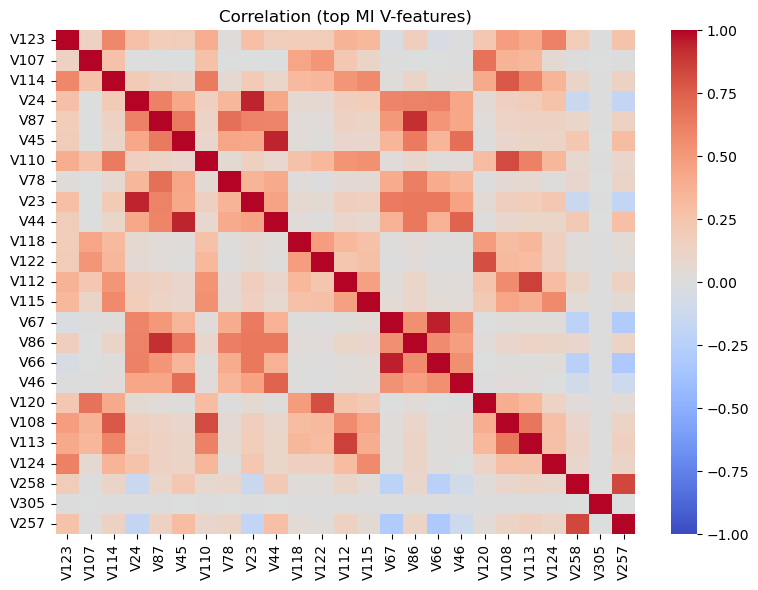

In [57]:
#checks
assert "train" in globals(), "train is not defined"
assert "isFraud" in train.columns, "isFraud column missing"

v_cols = [c for c in train.columns if c.startswith("V")]
assert len(v_cols) > 0, "No V* columns found"

#sample for speed
n = 100_000
#works on a 100k-row sample instead of the full dataset since mutual_info_classif is slow to run on everything
tmp = train.sample(n, random_state=0) if len(train) > n else train.copy()

X = tmp[v_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype("float32")
y = pd.to_numeric(tmp["isFraud"], errors="coerce").fillna(0).astype("int8")

mi = mutual_info_classif(X, y, discrete_features=False, random_state=0)
imp = pd.Series(mi, index=v_cols).sort_values(ascending=False)

topV = imp.head(25).index.tolist()
corr = tmp[topV].replace([np.inf, -np.inf], np.nan).fillna(0).corr().clip(-1, 1)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation (top MI V-features)")
plt.tight_layout()
plt.show()

Here, warm clusters indicate groups of highly correlated `V`-features carrying overlapping information, and near-neutral/weak-correlation regions indicate more independent signal.

This supports dimensionality reduction or representative-feature selection to avoid multicollinearity while preserving predictive power.

#### V-group reductions - materialize best features
This step creates the final reduced `V` features in train based on the best method chosen per `V`-group (mean, ucmean, or pca1).
For each group, it builds a clean matrix (median-imputed) and then computes the selected reduction, writing new columns like `Vgrp001_pca1`, `Vgrp003_mean`, etc.

In [58]:
#assume `groups` (V groups) and `reduced` dict from earlier step exist
best_feats = sorted(reduced.keys())  # ['Vgrp001_pca1', 'Vgrp002_mean', ...]
print("Adding reduced V features:", len(best_feats))

#recompute each reduced feature on the full train for consistency
from sklearn.decomposition import PCA

def make_group_matrix(df, cols):
    X = df[cols].copy()
    X = X.fillna(X.median(numeric_only=True))
    return X

#for each V-group, applies whichever reduction method (mean/ucmean/pca1) was found best in the step above, now computed on the full training set instead of just train/val
for gi, g in enumerate(groups, 1):
    key_any = [k for k in best_feats if k.startswith(f"Vgrp{gi:03d}_")]
    if not key_any:
        continue
    key = key_any[0]
    method = key.split("_", 1)[1]  # 'pca1', 'mean', 'ucmean'

    sub = [c for c in g if c in train.columns]
    if len(sub) < 1:
        continue
    X_full = make_group_matrix(train, sub)

    if method == "mean":
        train[key] = X_full.mean(axis=1).astype("float32")

    elif method == "ucmean":
        #simple uncorrelated subset (same helper idea as before)
        corr = X_full.corr().abs()
        keep, used = [], set()
        for c in corr.columns:
            if c in used: 
                continue
            keep.append(c)
            used.update(list(corr.index[corr[c] > 0.85]))
        train[key] = X_full[keep].mean(axis=1).astype("float32")

    elif method == "pca1":
        p = PCA(n_components=1, random_state=0)
        comp = p.fit_transform(X_full)[:,0]
        train[key] = comp.astype("float32")

print("Done. Example columns:", [c for c in train.columns if c.startswith("Vgrp")][:6])

Adding reduced V features: 11
Done. Example columns: ['Vgrp001_pca1', 'Vgrp002_pca1', 'Vgrp003_mean', 'Vgrp004_mean', 'Vgrp005_mean', 'Vgrp006_pca1']


The message confirms how many reduced `V` features were added and shows examples of the created column names. This demonstrates the group-level reduction idea end to end - rebuild it properly (a single method, fit on the train split only) for actual modeling, since this version's method selection used validation labels.

#### V-reductions - monthly stability plot for top few
These plots track the monthly mean of selected reduced `V`-features (`Vgrp`) to assess temporal stability after dimensionality reduction.

The goal is to check whether engineered group features remain reasonably consistent over time or show abrupt regime shifts.

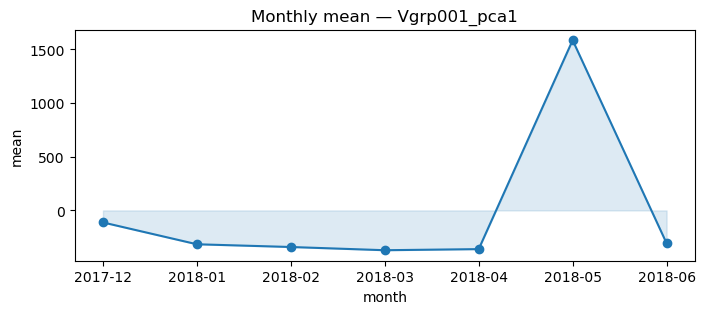

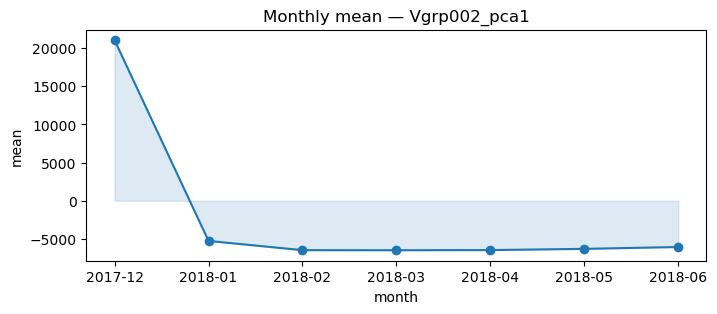

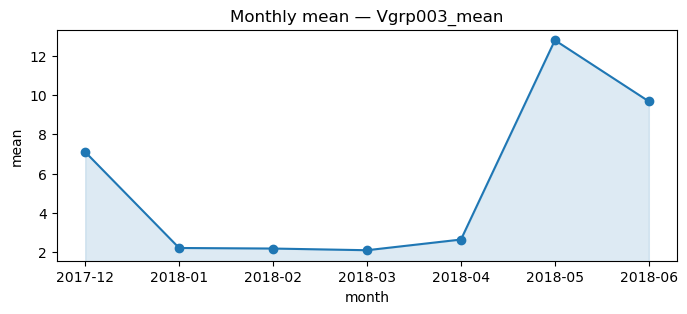

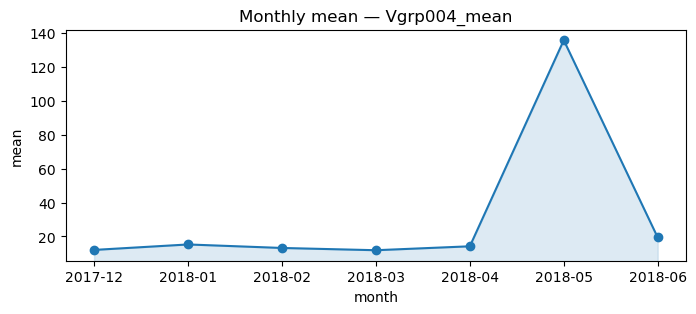

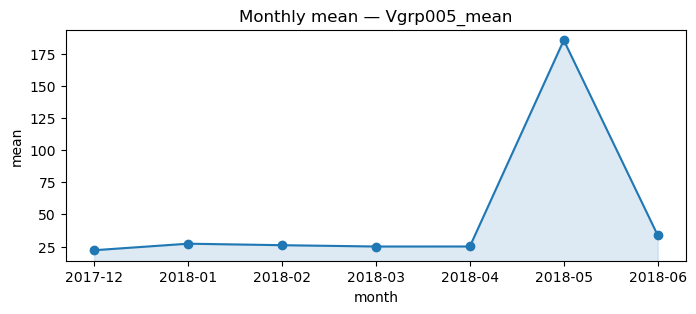

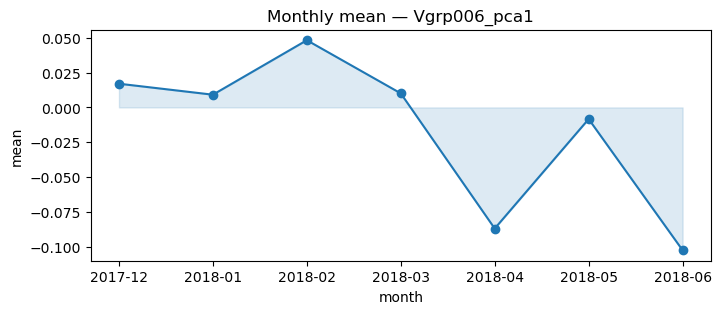

In [60]:
top_reduced = [c for c in train.columns if c.startswith("Vgrp")][:6] #the first 6 reduced V-group features (created earlier) to spot-check for temporal stability

for c in top_reduced:
    m = (train.assign(month=train["event_time"].dt.to_period("M").astype(str)) #computes the average value of this feature within each calendar month
               .groupby("month")[c].mean())  #the trend line shows how its scale shifts month to month
    ax = m.plot(marker="o", figsize=(8,3), title=f"Monthly mean \u2014 {c}")
    ylim = ax.get_ylim()  #remember the tight auto-scaled range before adding the fill
    ax.fill_between(range(len(m)), m.values, color="#1f77b4", alpha=0.15)
    ax.set_ylim(ylim)  #restore it so the shaded area doesn't pull the axis down to 0
    ax.set_ylabel("mean"); ax.set_xlabel("month")
    plt.show()

- Several reduced features display noticeable spikes (especially around one month), indicating potential temporal drift or seasonality.
- Other reduced features vary more smoothly and appear more stable.

Features with sharp jumps should be monitored in drift diagnostics and possibly down-weighted/regularized if they hurt out of time generalization.

## Feature audit conclusions
#### Main outcomes of this feature audit:

- Data integrity checks support a reliable base dataset, as there no problematic key duplication and expected structure after merge.
- Missingness is informative in multiple variables and should be treated as signal, not only as noise.
- Several features show temporal instability, so time-aware validation is necessary.
- Categorical features benefit from normalization and rare-category bucketing to improve stability and reduce sparsity.
- V-block features are highly redundant; group-wise dimensionality reduction (comparing PCA, an uncorrelated-subset mean, and a simple mean per group) provides a compact and practical representation, with per-group validation AUC used to compare which method captures the most signal.
- The selected artifacts from this notebook are used directly in preprocessing and modeling for reproducible downstream steps.

#### Audit outputs

In [61]:
from pathlib import Path
import json

ART = PROJECT_DIR / "artifacts"
ART.mkdir(parents=True, exist_ok=True)

#selected feature lists
all_features = [c for c in train.columns if c != "isFraud"]
numeric_features = [c for c in all_features if pd.api.types.is_numeric_dtype(train[c])]
categorical_features = [c for c in all_features if c not in numeric_features]
raw_v_cols = [c for c in all_features if c.startswith("V") and not c.startswith("Vgrp")]
#reuses the near-constant columns found in the constant/near-constant check earlier in the notebook, or defaults to an empty list if that cell was not run
near_constant_cols = [c for c in near if c in all_features] if "near" in globals() else []
#final feature list for modeling: excludes the raw V columns (replaced by the PCA/mean Vgrp reductions) and near-constant columns identified earlier
modeling_features = [c for c in all_features if c not in set(raw_v_cols) | set(near_constant_cols)]

selected = {
    "all_features": all_features,
    "modeling_features": modeling_features,
    "dropped_raw_v_cols": raw_v_cols,
    "dropped_near_constant_cols": near_constant_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
}
(ART / "selected_features.json").write_text(json.dumps(selected, indent=2))
print(f"all_features={len(all_features)}  modeling_features={len(modeling_features)} "
      f"(dropped {len(raw_v_cols)} raw V-cols in favor of Vgrp reductions, "
      f"{len(near_constant_cols)} near-constant cols)")

#rare-bucketing keep maps (from frequent categories >=0.1%)
rare_cols = [c for c in ["ProductCD","card4","card6","P_email_prov","device_brand","device_platform","DeviceType"] if c in train.columns]
rare_keep = {}
for c in rare_cols:
    freq = train[c].fillna("__MISS__").value_counts(normalize=True)
    keep = freq[freq >= 0.001].index.astype(str).tolist()
    rare_keep[c] = {"min_freq": 0.001, "keep_values": keep, "fill_label": "__OTHER__", "missing_label": "__MISS__"}
(ART / "rare_bucket_keep.json").write_text(json.dumps(rare_keep, indent=2))

#frequent-category fraud-rate diagnostics (for audit reproducibility)
rate_tables = []
for c in [x for x in ["card1","card2","card4","card6","P_email_prov","device_brand","device_platform"] if x in train.columns]:
    vc = train[c].value_counts(dropna=False)
    top = vc[vc >= 1000].index
    fr = (train[train[c].isin(top)].groupby(c)["isFraud"].mean().rename("fraud_rate").reset_index())
    fr["feature"] = c
    #renames this feature's column to a fixed name "category" so tables from different features can be stacked together into one combined csv
    rate_tables.append(fr[["feature", c, "fraud_rate"]].rename(columns={c: "category"}))
if rate_tables:
    pd.concat(rate_tables, ignore_index=True).to_csv(ART / "audit_target_rates_frequent_categories.csv", index=False)

#V-block artifacts
v_cols = [c for c in train.columns if c.startswith("V")]
if v_cols:
    #save grouped V columns if variable `groups` exists
    if "groups" in globals():
        (ART / "v_groups.json").write_text(json.dumps(groups, indent=2))
    #save reduced V features actually materialized in train
    v_reduced = [c for c in train.columns if c.startswith("Vgrp")]
    pd.DataFrame({"feature": v_reduced}).to_csv(ART / "v_reduced_features.csv", index=False)

#drift table save
#checks which of these drift-summary variable names actually exists in memory (depends on which PSI cells above were run) and saves whichever one is found
for var_name in ["psi_summary", "drift_summary", "psi_df"]:
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        globals()[var_name].to_csv(ART / f"{var_name}.csv", index=False)

print("Feature-audit artifacts saved to:", ART)

all_features=465  modeling_features=125 (dropped 339 raw V-cols in favor of Vgrp reductions, 11 near-constant cols)
Feature-audit artifacts saved to: /Users/kravchan/Downloads/Supervised Research/project/artifacts


##### End of notebook